## Regresión Lineal

In [28]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a Python data visualization library based on matplotlib. 
%matplotlib inline  
# Import train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

#### 0. Importamos los datos 

In [29]:
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\04 Aprendizaje supervisado'

In [30]:
path = 'data\\USA_Housing.csv'
#'C:\\Users\\tomas\\ML\\cluster\\Scripts\\data'

df = pd.read_csv(path)
df.head(5)
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


#### 1. Analizamos los datos

In [31]:
#chequeamos nulos 
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Para este ejemplo, por razones de simplicidad, quitamos la variable direccion (address). Pero esta informacion puede3 ser muy valiosa con el tratamiento adecuado.  

In [34]:
#quito las variable address 
df2 = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population', 'Price' ]]
df2

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


<Axes: >

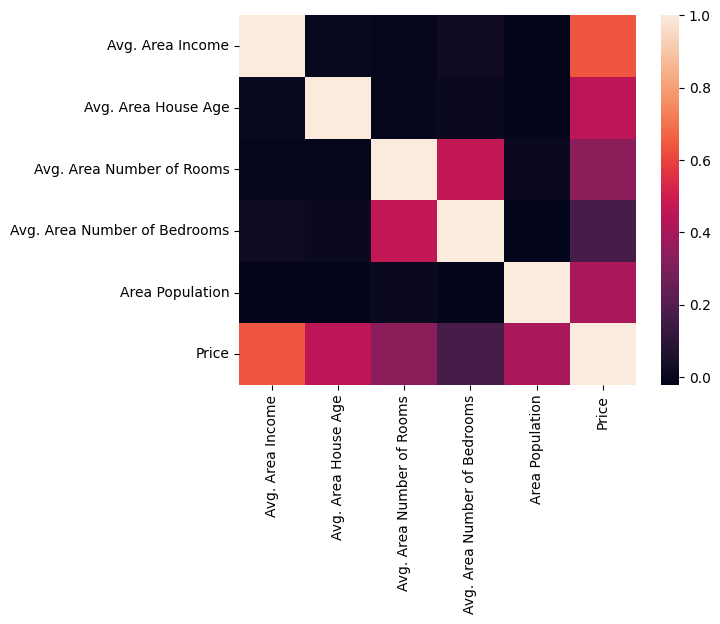

In [35]:
# heatmap de correlaciones
sns.heatmap(df2.corr())

In [36]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

In [37]:

# Split up the data into a training set
#random state es una vaor semilla para hacer la separaciion. Hace que cada vez que lo ejecutemos los conjuntos de entrenaiento y tes sean los mismos 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

#### 2. Modelo linear regression

In [38]:
lm = LinearRegression()

In [39]:
lm.fit(X_train,y_train) 

LinearRegression()

#### 2.1 Coeficientes

In [40]:
print(lm.intercept_)

-2640159.796852963


In [41]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


In [42]:
y_pred = lm.predict(X_test)
y_pred

array([1260960.70567628,  827588.75560322, 1742421.24254349, ...,
        372191.40626905, 1365217.15140899, 1914519.54178899],
      shape=(2000,))

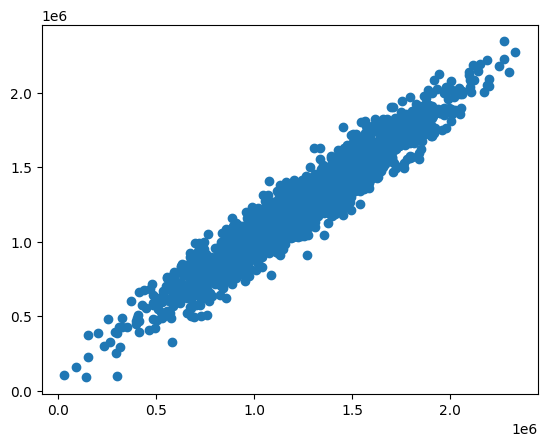

In [43]:
# y estimada vs y real
plt.scatter(y_test,y_pred)

#### 2.2 Evaluación del modelo

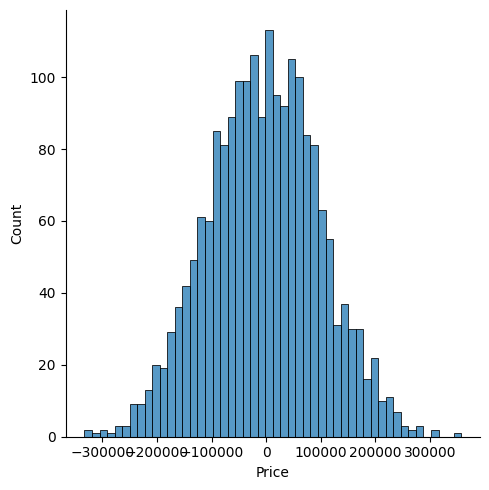

In [44]:
# histograma de residuales
sns.displot((y_test-y_pred),bins=50);

#### 2.3 Métricas de error   



**Mean Absolute Error** (MAE) es la media del valor absoluto de los errores:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) es la media de los cuadrados de los errores:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) es la raiz cuadradade los errores al cuadrado:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$


In [45]:
#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 82288.22251914945
MSE: 10460958907.208805
RMSE: 102278.82922290813


In [46]:
r2_tr = lm.score(X_train, y_train)
print("R^2:", r2_tr)

R^2: 0.9181223200568411


In [47]:
r2_ts = lm.score(X_test, y_test)
print("R^2:", r2_ts)

R^2: 0.9176824009649255


In [48]:
r2_=r2_score(y_test, y_pred)
r2_

0.9176824009649255

#### 3. Modelo SGDRegresor  
Cuando el numero de variables input es muy grande se puede emplear SGDregrressor que aplica el metrodo del gradiente para encontrar el optimo.

**- constant (Constante):**
La tasa de aprendizaje permanece fija durante todo el entrenamiento.
Se especifica con el parámetro eta0, que define su valor constante.  
**- optimal (Adaptativa):**
Calcula automáticamente una tasa de aprendizaje óptima en función de las iteraciones y los datos de entrenamiento.  
**- invscaling (Escalado inverso):**
Reduce la tasa de aprendizaje a medida que aumenta el número de iteraciones.  
**- adaptive (Adaptativo moderno):**
Reduce la tasa de aprendizaje únicamente cuando no mejora el error durante varias iteraciones consecutivas. Este es un método más reciente, útil en ciertos escenarios.  

#### Escalado de los datos
El modelo SGD regresor es sensible al escalado de los datos 

In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
#y_scaled = scaler_y.fit_transform(y)
y_scaled = scaler_y.fit_transform(y.to_frame())

In [72]:
y_scaled

array([[0.42521032],
       [0.60736859],
       [0.42519175],
       ...,
       [0.41367241],
       [0.48212679],
       [0.52301078]], shape=(5000, 1))

In [76]:
# Dividir y entrenar
from sklearn.linear_model import SGDRegressor

X_train_S, X_test_S, y_train_S, y_test_S = train_test_split(X_scaled, y_scaled, random_state=42)

model = SGDRegressor(max_iter=10000, learning_rate='optimal', penalty='l2')
model.fit(X_train_S, y_train_S)

C:\Users\tomas\ML\cluster\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(learning_rate='optimal', max_iter=10000)

In [91]:
y_test_S.shape

(1250, 1)

In [104]:

# Predicción (y desescalado)
y_pred_scaled = model.predict(X_test_S).reshape(-1, 1)
#y_pred_original = scaler_y.inverse_transform(y_pred_scaled)
y_pred_scaled

C:\Users\tomas\ML\cluster\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


array([[-6.78308462e+13],
       [-6.59637916e+13],
       [-5.93210947e+13],
       ...,
       [-8.02021280e+13],
       [-6.41379880e+13],
       [-5.60048128e+13]], shape=(1250, 1))

In [92]:
y_pred_original = scaler_y.inverse_transform(y_pred_scaled)
y_test_original=scaler_y.inverse_transform(y_test_S)
#y_pred_scaled = model.predict(X_test_S)
#y_pred_original = scaler_y.inverse_transform(y_pred_scaled)

print("Predicciones reales:", y_pred_original)

Predicciones reales: [[1358326.23382584]
 [1283186.0361147 ]
 [1290442.88875162]
 ...
 [1335232.67853624]
 [1110729.82171615]
 [1340949.60284582]]


In [93]:
r2_=r2_score(y_test_original, y_pred_original)
r2_

0.8807430130779167

El resultado podría mejorarse, vamos a hacer un gridsearch para optimizar los parámetros

In [94]:
from sklearn.model_selection import GridSearchCV
sgd = SGDRegressor()

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'loss': ['squared_error', 'huber'],  # Tipos de función de pérdida
    'penalty': ['l2', 'l1', 'elasticnet'],  # Regularización
    'alpha': [0.0001, 0.001, 0.01],  # Fuerza de la regularización
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],  # Tipos de tasa de aprendizaje
    'eta0': [0.01, 0.1, 1.0]  # Tasa de aprendizaje inicial
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Métrica de evaluación
    cv=5,  # Validación cruzada con 5 pliegues
    n_jobs=-1,  # Usar todos los núcleos disponibles
    verbose=1  # Mostrar progreso
)


In [96]:

# Ejecutar la búsqueda de hiperparámetros
grid_search.fit(X_train_S, y_train_S)

# Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor puntuación (MSE negativo):", grid_search.best_score_)

# Evaluar en el conjunto de prueba
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros encontrados: {'alpha': 0.0001, 'eta0': 0.1, 'learning_rate': 'adaptive', 'loss': 'squared_error', 'penalty': 'l2'}
Mejor puntuación (MSE negativo): -0.0017219161229458367


C:\Users\tomas\ML\cluster\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [109]:
y_pred_scaled = best_model.predict(X_test_S).reshape(-1, 1)
y_pred_original = scaler_y.inverse_transform(y_pred_scaled)
#y_test_original=scaler_y.inverse_transform(y_test_S)

r2_=r2_score(y_test_original, y_pred_original)
print("R2:", r2_)

R2: 0.916928277523812


Con gridSearch lo mejoramos, pasamos de 0.88 a 0.92

In [110]:
print(best_model.intercept_)

[-0.57763632]


In [111]:
print(best_model.intercept_)
coeff_df = pd.DataFrame(best_model.coef_,X.columns,columns=['Coefficient'])
coeff_df

[-0.57763632]


,Coefficient
Avg. Area Income,0.787672
Avg. Area House Age,0.460453
Avg. Area Number of Rooms,0.363160
Avg. Area Number of Bedrooms,0.004350
Area Population,0.428279


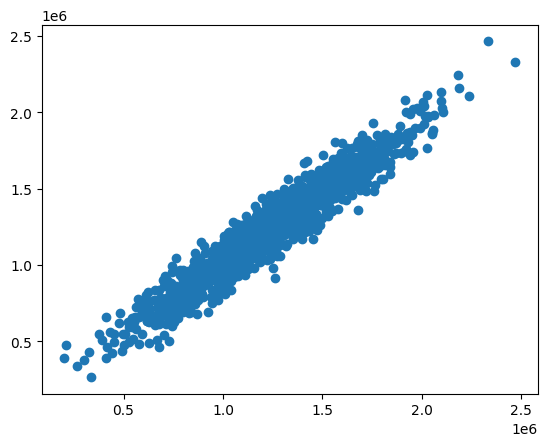

In [112]:
plt.scatter(y_test_original,y_pred_original)

In [122]:
y_pred_original

array([[1308353.49700856],
       [1237085.15795952],
       [1243865.51693567],
       ...,
       [1261600.27093229],
       [1077349.55774934],
       [1258380.36111168]], shape=(1250, 1))

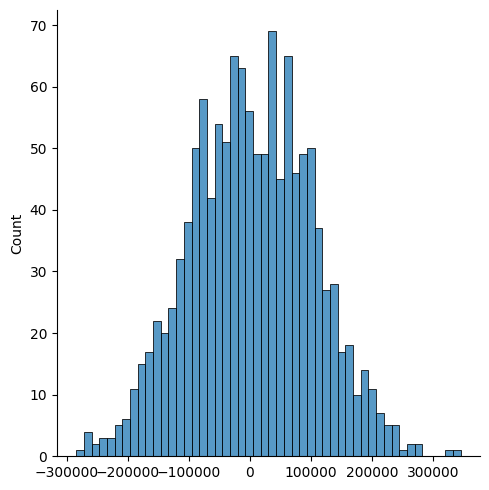

In [123]:
# histograma de residuales
sns.displot((y_test_original.reshape(-1)-y_pred_original.reshape(-1)),bins=50);

#### 4. Modelo de Regresión Lasso y Ridge
Probamos ahora lasso y ridge, aunque con SGDRegressor se puede hacer indicando pentalty L1 o L2.

In [124]:
from sklearn.linear_model import Ridge, Lasso
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.metrics import mean_squared_error

# Ridge
ridge = Ridge(alpha=1.0)  # 'alpha' es el parámetro de regularización equivalente a 'lambda'
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
r2_=r2_score(y_test, y_pred_ridge)
print("R2:", r2_)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
r2_=r2_score(y_test, y_pred_lasso)
print("R2:", r2_)

Ridge MSE: 10089716572.554762
R2: 0.9179914220241199
Lasso MSE: 10089010510.994362
R2: 0.9179971608478139


In [125]:
print(ridge.intercept_)
coeff_df = pd.DataFrame(ridge.coef_,X.columns,columns=['Coefficient'])
coeff_df

-2634603.83134852


,Coefficient
Avg. Area Income,21.652123
Avg. Area House Age,164624.137539
Avg. Area Number of Rooms,119585.966102
Avg. Area Number of Bedrooms,2454.734742
Area Population,15.270255


In [126]:
print(lasso.intercept_)
coeff_df = pd.DataFrame(lasso.coef_,X.columns,columns=['Coefficient'])
coeff_df

-2635071.583212803


,Coefficient
Avg. Area Income,21.652206
Avg. Area House Age,164666.378500
Avg. Area Number of Rooms,119623.932897
Avg. Area Number of Bedrooms,2440.341894
Area Population,15.270313


#### 5. Resumen

* **LinearRegression()**    
    * Modelo clásico de regresión lineal ordinaria.
    * Minimiza el error cuadrático (MSE) sin penalizaciones.
    * Puede sobreajustarse si hay muchas variables o colinealidad.
    *  Útil cuando hay pocos predictores y no hay riesgo de sobreajuste.
* **SGDRegressor()**  
    * Usa descenso de gradiente estocástico (SGD) para ajustar los coeficientes.
    * Ideal para datasets muy grandes o en streaming.
    * Permite aplicar penalizaciones como 'l2' (Ridge), 'l1' (Lasso) o 'elasticnet'.
    * Es más sensible al escalado, así que suele ir acompañado de StandardScaler o MinMaxScaler
    * Úsalo cuando tienes gran cantidad de datos o quieres control granular sobre la optimización.  
* **Ridge(alpha=1.0)**  
    * Regresión lineal con penalización L2.
    * Penaliza coeficientes grandes sin eliminarlos.
    * Reduce el sobreajuste al suavizar la influencia de las variables.
    * Muy útil cuando hay multicolinealidad o muchas variables poco relevantes.  
* **Lasso(alpha=0.1)**
    * Regresión con penalización L1.
    * Puede llevar coeficientes exactamente a cero, haciendo selección de variables.
    * Cuanto mayor el alpha, más agresiva es la penalización.
    * Ideal si quieres reducir el número de variables y obtener un modelo más interpretable.  